# 📬 From inbox chaos to self-improving enterprise ready decision-making Multi-Agent Self Learning RL based Email Triage OpenEnv — Final Hackathon Colab

This notebook is built for the Scaler x Meta PyTorch OpenEnv Hackathon final submission.

It demonstrates:

- OpenEnv-style enterprise email triage environment
- Multi-agent decision flow: classifier + scheduler + baselines + PPO
- Reward model and evaluation metrics
- PPO training and reward plots
- Self-improvement curriculum tracking
- Deployed Hugging Face Space API checks
- Optional Hugging Face TRL mini-training cell for judge reproducibility

**GitHub:** https://github.com/vishalgulatigithub/email-triage-openenv-environment  
**Hugging Face Space:** https://huggingface.co/spaces/vishalgulatinitj/email-triage-openenv  
**Live App:** https://vishalgulatinitj-email-triage-openenv.hf.space

**Api endpoints:** https://vishalgulatinitj-email-triage-openenv.hf.space/api/docs#/

In [43]:
# Runtime configuration
REPO_URL = "https://github.com/vishalgulatigithub/email-triage-openenv-environment"
REPO_DIR = "email-triage-openenv-environment"

HF_APP_BASE = "https://vishalgulatinitj-email-triage-openenv.hf.space"

# Set True for a full PPO run. Keep False if you only want fast judge verification.
RUN_TRAINING = True

# Optional mini HF TRL demonstration using the environment-generated instruction data.
# This is lightweight and separate from the PPO pipeline.
RUN_TRL_MINI_DEMO = False

## 1. Clone repository and install dependencies

In [44]:
import os, sys, subprocess, json, textwrap, pathlib, time

def run(cmd, timeout=None, check=True):
    print("\n$ " + " ".join(cmd) if isinstance(cmd, list) else "\n$ " + cmd)
    result = subprocess.run(
        cmd,
        shell=isinstance(cmd, str),
        text=True,
        capture_output=True,
        timeout=timeout
    )
    print(result.stdout)
    if result.stderr:
        print(result.stderr)
    if check and result.returncode != 0:
        raise RuntimeError(f"Command failed with code {result.returncode}: {cmd}")
    return result

if not os.path.exists(REPO_DIR):
    run(["git", "clone", REPO_URL, REPO_DIR])
else:
    print("Repository already exists. Pulling latest changes...")
    run(["git", "-C", REPO_DIR, "pull"], check=False)

os.chdir(REPO_DIR)
print("Current directory:", os.getcwd())


$ git clone https://github.com/vishalgulatigithub/email-triage-openenv-environment email-triage-openenv-environment

Cloning into 'email-triage-openenv-environment'...

Current directory: /content/email-triage-openenv-environment/email-triage-openenv-environment/email-triage-openenv-environment/email-triage-openenv-environment


In [45]:
# Install project dependencies
run([sys.executable, "-m", "pip", "install", "--upgrade", "pip"], timeout=300)
run([sys.executable, "-m", "pip", "install", "-r", "requirements.txt"], timeout=600)

# Extra dependencies for Colab plotting / requests if missing
run([sys.executable, "-m", "pip", "install", "-q", "requests"], timeout=300, check=False)


$ /usr/bin/python3 -m pip install --upgrade pip


$ /usr/bin/python3 -m pip install -r requirements.txt


$ /usr/bin/python3 -m pip install -q requests



CompletedProcess(args=['/usr/bin/python3', '-m', 'pip', 'install', '-q', 'requests'], returncode=0, stdout='', stderr='')

## 2. Verify required project files

In [46]:
required_paths = [
    "openenv.yaml",
    "Dockerfile",
    "README.md",
    "requirements.txt",
    "app/env.py",
    "app/main.py",
    "app/reward.py",
    "app/tasks.py",
    "agents/classifier_agent.py",
    "agents/scheduler_agent.py",
    "agents/rule_based.py",
    "agents/random_agent.py",
    "training/train_ppo.py",
    "training/evaluate.py",
    "visualization/dashboard.py",
]

missing = [p for p in required_paths if not os.path.exists(p)]
print("Missing files:", missing if missing else "None ✅")
assert not missing, f"Missing required files: {missing}"

Missing files: None ✅


## 3. Check deployed Hugging Face Space API

In [47]:
import requests, json

def get_json(url):
    print("GET", url)
    r = requests.get(url, timeout=30)
    print("Status:", r.status_code)
    print(r.text[:500])
    return r

# Dashboard HTML
dashboard_resp = requests.get(HF_APP_BASE + "/", timeout=30)
print("Dashboard status:", dashboard_resp.status_code)

# FastAPI OpenAPI through /api
openapi_resp = get_json(HF_APP_BASE + "/api/openapi.json")
if openapi_resp.ok:
    spec = openapi_resp.json()
    print("\nAvailable API endpoints:")
    for path, ops in spec.get("paths", {}).items():
        for method in ops.keys():
            print(method.upper(), "/api" + path)

Dashboard status: 200
GET https://vishalgulatinitj-email-triage-openenv.hf.space/api/openapi.json
Status: 200
{"openapi":"3.1.0","info":{"title":"From inbox chaos to self-improving enterprise ready decision-making Multi-agent self Learning and Improving Email Triage OpenEnv","version":"2.0.0"},"servers":[{"url":"/api"}],"paths":{"/":{"get":{"summary":"Root","operationId":"root__get","responses":{"200":{"description":"Successful Response","content":{"application/json":{"schema":{}}}}}}},"/reset":{"post":{"summary":"Reset Env","operationId":"reset_env_reset_post","responses":{"200":{"description":"Success

Available API endpoints:
GET /api/
POST /api/reset
GET /api/state
POST /api/step
GET /api/evaluate_agent
GET /api/compare_agents
GET /api/dashboard/view


## 4. Environment smoke test

In [48]:
# Basic import smoke test for environment and tasks.
# This does not assume a specific private implementation, but verifies core modules load.

modules = [
    "app.env",
    "app.models",
    "app.features",
    "app.reward",
    "app.tasks",
    "agents.classifier_agent",
    "agents.scheduler_agent",
    "agents.rule_based",
    "agents.random_agent",
    "training.state_encoder",
]
for m in modules:
    __import__(m)
    print("Imported", m, "✅")

# Try creating the environment if available
try:
    from app.env import EmailEnv
    env = EmailEnv()
    print("EmailEnv created ✅")
    if hasattr(env, "reset"):
        state = env.reset()
        print("Reset output type:", type(state))
        print(str(state)[:500])
except Exception as e:
    print("Environment smoke test warning:", repr(e))

Imported app.env ✅
Imported app.models ✅
Imported app.features ✅
Imported app.reward ✅
Imported app.tasks ✅
Imported agents.classifier_agent ✅
Imported agents.scheduler_agent ✅
Imported agents.rule_based ✅
Imported agents.random_agent ✅
Imported training.state_encoder ✅
EmailEnv created ✅
Reset output type: <class 'dict'>
{'inbox': [{'id': 'seed-013-19d42aef-0-4-6675', 'sender': 'vip-client@enterprise.com', 'subject': 'Important: Urgent issue impacting our team today', 'body': 'This issue is impacting our team and needs urgent review today. A major client is impacted and leadership visibility is required. This is time-sensitive.', 'category': 'escalation', 'priority': 'high', 'urgency_score': 0.9, 'sender_importance': 2, 'deadline_steps': 1, 'adversarial': False, 'spam_score': 0.1, 'phishing_risk': 0.1, 'requires


## 5. Generate / verify synthetic task data

In [49]:
# If data/emails.json exists, inspect size.
import json, os

emails_path = "data/emails.json"
if os.path.exists(emails_path):
    with open(emails_path, "r", encoding="utf-8") as f:
        emails = json.load(f)
    print("Email dataset size:", len(emails))
    print("First sample:")
    print(json.dumps(emails[0], indent=2)[:1000] if emails else "No emails")
else:
    print("data/emails.json not found. Running app.tasks generation may create it.")
    run([sys.executable, "-m", "app.tasks"], check=False)

Email dataset size: 20
First sample:
{
  "id": "seed-001",
  "sender": "customer@shopmail.com",
  "subject": "Damaged item received and need replacement",
  "body": "I received a damaged item and need a replacement as soon as possible.",
  "category": "complaint",
  "priority": "high"
}


## 6. Run baseline

In [50]:
# Baseline gives random/rule comparison before PPO.
run([sys.executable, "-m", "baseline.run_baseline"], timeout=600, check=False)


$ /usr/bin/python3 -m baseline.run_baseline
Episode 1: reward=35.88
Episode 2: reward=49.09
Episode 3: reward=28.99
Episode 4: reward=37.69
Episode 5: reward=-0.43
Episode 6: reward=-16.11
Episode 7: reward=80.87
Episode 8: reward=-5.53
Episode 9: reward=4.41
Episode 10: reward=-40.69

Average rule-based reward over 10 episodes: 17.42



CompletedProcess(args=['/usr/bin/python3', '-m', 'baseline.run_baseline'], returncode=0, stdout='Episode 1: reward=35.88\nEpisode 2: reward=49.09\nEpisode 3: reward=28.99\nEpisode 4: reward=37.69\nEpisode 5: reward=-0.43\nEpisode 6: reward=-16.11\nEpisode 7: reward=80.87\nEpisode 8: reward=-5.53\nEpisode 9: reward=4.41\nEpisode 10: reward=-40.69\n\nAverage rule-based reward over 10 episodes: 17.42\n', stderr='')

## 7. Train PPO and log rewards

In [51]:
# PPO training. This produces:
# - training/checkpoints/ppo_email_triage.pt
# - training/checkpoints/episode_rewards.csv
# - training/checkpoints/curriculum_log.txt

if RUN_TRAINING:
    run([sys.executable, "-m", "training.train_ppo"], timeout=1800, check=False)
else:
    print("RUN_TRAINING=False. Skipping PPO training.")


$ /usr/bin/python3 -m training.train_ppo
Self-Improvement Curriculum Level: 1
Episode 1/400 | reward=-48.54 | avg_last_10=-48.54
Self-Improvement Curriculum Level: 1
Episode 2/400 | reward=-17.01 | avg_last_10=-32.77
Self-Improvement Curriculum Level: 1
Episode 3/400 | reward=1.91 | avg_last_10=-21.21
Self-Improvement Curriculum Level: 1
Episode 4/400 | reward=-34.63 | avg_last_10=-24.57
Self-Improvement Curriculum Level: 1
Episode 5/400 | reward=3.18 | avg_last_10=-19.02
Self-Improvement Curriculum Level: 1
Episode 6/400 | reward=-88.10 | avg_last_10=-30.53
Self-Improvement Curriculum Level: 1
Episode 7/400 | reward=-71.76 | avg_last_10=-36.42
Self-Improvement Curriculum Level: 1
Episode 8/400 | reward=-47.77 | avg_last_10=-37.84
Self-Improvement Curriculum Level: 1
Episode 9/400 | reward=-68.47 | avg_last_10=-41.24
Self-Improvement Curriculum Level: 1
Episode 10/400 | reward=-17.22 | avg_last_10=-38.84
Self-Improvement Curriculum Level: 1
Episode 11/400 | reward=-13.42 | avg_last_10

## 8. Plot reward and curriculum curves


$ /usr/bin/python3 visualization/plot_rewards.py
Figure(1200x600)
Saved reward plot to visualization/reward_curve.png


$ /usr/bin/python3 visualization/plot_curriculum.py
Figure(1000x500)
Saved curriculum plot to visualization/curriculum_progression.png


$ /usr/bin/python3 -m visualization.compare_agents
Figure(800x500)
Saved total_reward chart to visualization/total_reward_comparison.png
Figure(800x500)
Saved urgent_handled chart to visualization/urgent_handled_comparison.png
Figure(800x500)
Saved urgent_missed chart to visualization/urgent_missed_comparison.png
Figure(800x500)
Saved sla_breaches chart to visualization/sla_breaches_comparison.png

Displaying visualization/reward_curve.png


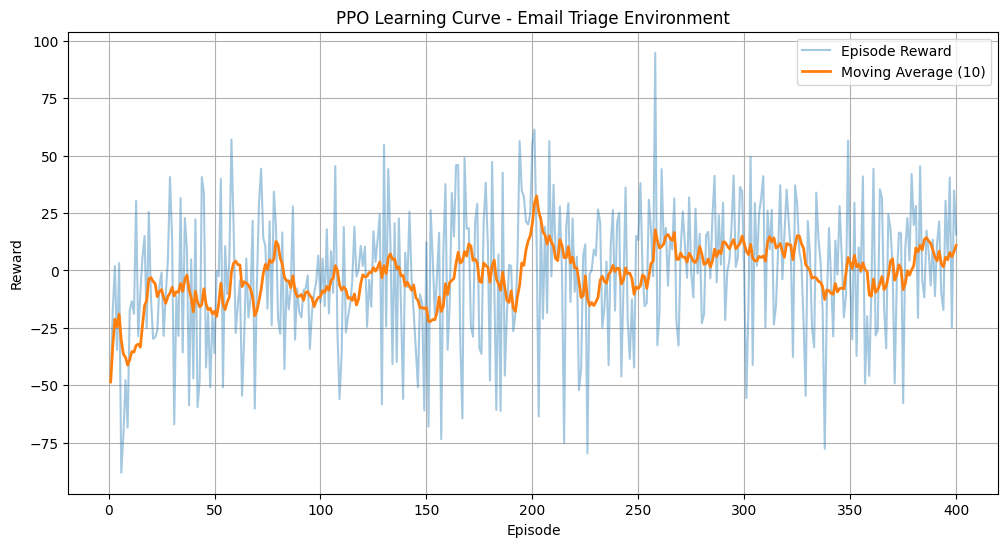

Displaying visualization/curriculum_progression.png


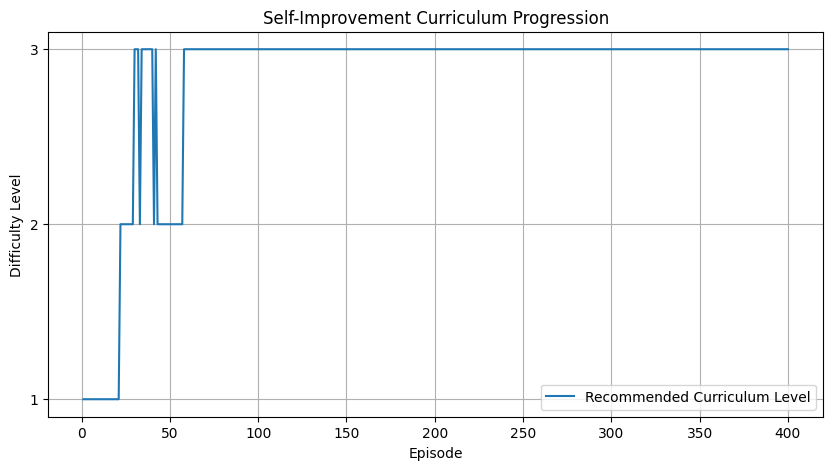

Displaying visualization/total_reward_comparison.png


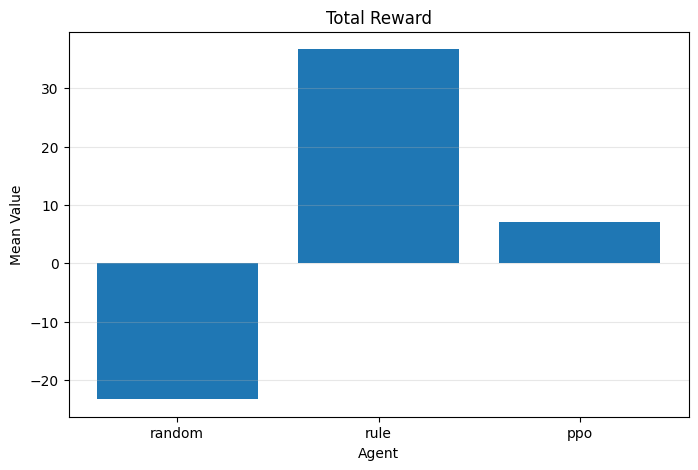

Displaying visualization/urgent_handled_comparison.png


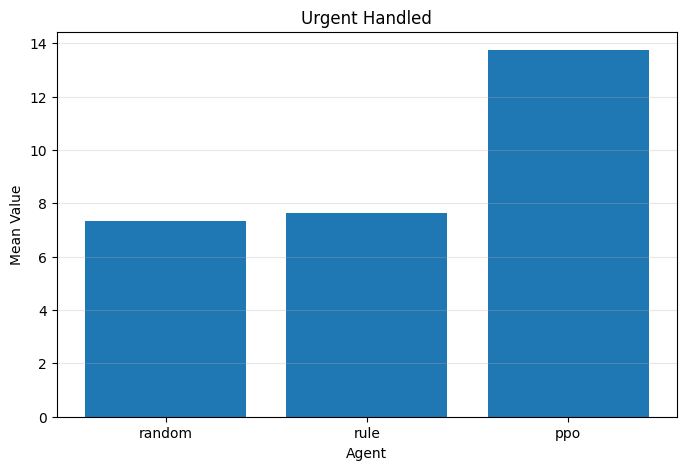

Displaying visualization/urgent_missed_comparison.png


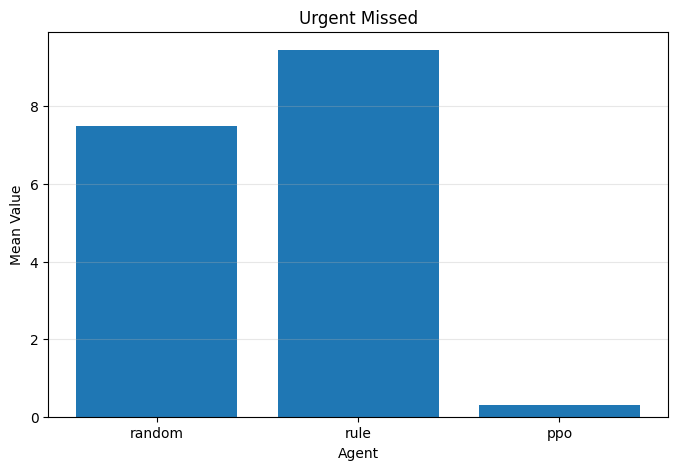

Displaying visualization/sla_breaches_comparison.png


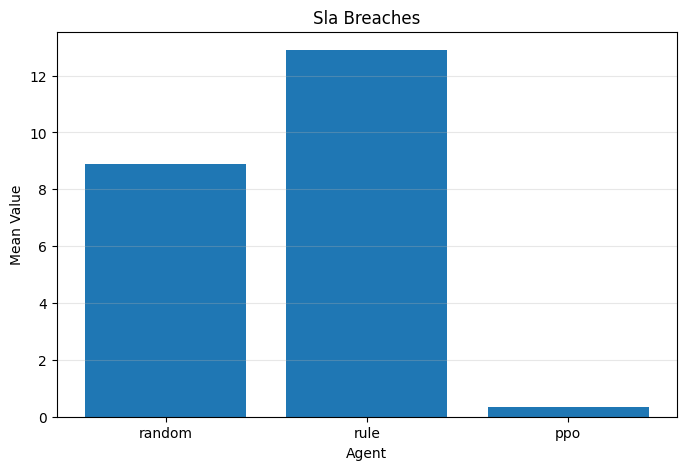

In [52]:
# Generate plot files from training logs.
# Generate plot files from training logs.
run([sys.executable, "visualization/plot_rewards.py"], timeout=300, check=False)
run([sys.executable, "visualization/plot_curriculum.py"], timeout=300, check=False)

# Generate comparison plots for random vs rule-based vs PPO agents.
run([sys.executable, "-m", "visualization.compare_agents"], timeout=600, check=False)

from IPython.display import display, Image

for img in [
    "visualization/reward_curve.png",
    "visualization/curriculum_progression.png",
    "visualization/total_reward_comparison.png",
    "visualization/urgent_handled_comparison.png",
    "visualization/urgent_missed_comparison.png",
    "visualization/sla_breaches_comparison.png",
]:
    if os.path.exists(img):
        print("Displaying", img)
        display(Image(filename=img))
    else:
        print("Plot not found:", img)

## 9. Evaluate agents locally

In [53]:
# Compare random, rule-based and PPO agents.
eval_result = run([sys.executable, "-m", "training.evaluate"], timeout=900, check=False)
print(eval_result.stdout[-2000:])


$ /usr/bin/python3 -m training.evaluate
AGENT        AVG_REWARD      URGENT_HANDLED     URGENT_MISSED      SLA_BREACHES    SAFE_SCORE  
random       -18.79          7.80               7.80               9.70            -9.70       
rule         42.58           6.55               7.50               10.45           -11.40      
ppo          4.44            15.55              0.10               0.35            15.10       

AGENT        AVG_REWARD      URGENT_HANDLED     URGENT_MISSED      SLA_BREACHES    SAFE_SCORE  
random       -18.79          7.80               7.80               9.70            -9.70       
rule         42.58           6.55               7.50               10.45           -11.40      
ppo          4.44            15.55              0.10               0.35            15.10       



## 10. Evaluate deployed Hugging Face API endpoints

In [54]:
# These correspond to your deployed FastAPI routes under /api/*.
endpoints = [
    "/api/evaluate_agent?agent_type=random&num_episodes=10",
    "/api/evaluate_agent?agent_type=rule&num_episodes=10",
    "/api/evaluate_agent?agent_type=ppo&num_episodes=10&checkpoint_path=training/checkpoints/ppo_email_triage.pt",
    "/api/compare_agents?num_episodes=10&checkpoint_path=training/checkpoints/ppo_email_triage.pt",
]

for ep in endpoints:
    url = HF_APP_BASE + ep
    print("\nGET", url)
    try:
        r = requests.get(url, timeout=120)
        print("Status:", r.status_code)
        print(r.text[:1500])
    except Exception as e:
        print("Request failed:", repr(e))


GET https://vishalgulatinitj-email-triage-openenv.hf.space/api/evaluate_agent?agent_type=random&num_episodes=10
Status: 200
{"agent_type":"random","num_episodes":10,"aggregated":{"total_reward":{"mean":-14.685999999999993,"min":-49.28,"max":5.840000000000003},"steps":{"mean":30.0,"min":30,"max":30},"emails_seen":{"mean":30.0,"min":30,"max":30},"emails_processed":{"mean":30.0,"min":30,"max":30},"urgent_handled":{"mean":8.2,"min":3,"max":15},"urgent_missed":{"mean":7.6,"min":4,"max":11},"spam_ignored":{"mean":1.9,"min":0,"max":4},"phishing_replied":{"mean":1.2,"min":0,"max":2},"unnecessary_escalations":{"mean":3.5,"min":1,"max":6},"sla_breaches":{"mean":9.3,"min":7,"max":12},"cumulative_reward":{"mean":-14.685999999999993,"min":-49.28,"max":5.840000000000003},"safe_policy_score":{"mean":-8.700000000000001,"min":-8.700000000000001,"max":-8.700000000000001}},"raw_results":[{"agent_type":"random","total_reward":-11.189999999999994,"steps":30,"metrics":{"emails_seen":30,"emails_processed":3

## 11. Optional: Hugging Face TRL mini-training demo

The main project uses PPO for environment decision-making. This optional cell creates a tiny TRL-compatible instruction tuning example from email triage actions. It is intentionally lightweight so judges can run it in Colab if they want to verify a Hugging Face training loop.

In [55]:
if RUN_TRL_MINI_DEMO:
    run([sys.executable, "-m", "pip", "install", "-q", "transformers", "datasets", "accelerate", "trl"], timeout=600)

    from datasets import Dataset
    from transformers import AutoTokenizer, AutoModelForCausalLM
    from trl import SFTTrainer, SFTConfig

    samples = [
        {
            "subject": "ASAP: production incident blocking users",
            "body": "Customers cannot access checkout.",
            "action": "escalate",
            "reason": "critical production incident with SLA risk",
        },
        {
            "subject": "Verify your password now",
            "body": "Click this suspicious link to keep your account.",
            "action": "ignore",
            "reason": "phishing risk; do not reply",
        },
        {
            "subject": "Customer refund request",
            "body": "A customer needs help with a refund.",
            "action": "reply",
            "reason": "legitimate support request",
        },
        {
            "subject": "Weekly newsletter",
            "body": "Here is the weekly marketing update.",
            "action": "defer",
            "reason": "low urgency",
        },
    ] * 8

    texts = []
    for s in samples:
        texts.append(
            "### Email Triage Task\n"
            f"Subject: {s['subject']}\n"
            f"Body: {s['body']}\n"
            "Choose one action: reply, escalate, defer, ignore.\n"
            "### Answer\n"
            f"Action: {s['action']}\nRationale: {s['reason']}"
        )

    ds = Dataset.from_dict({"text": texts})

    model_id = "sshleifer/tiny-gpt2"
    tok = AutoTokenizer.from_pretrained(model_id)
    if tok.pad_token is None:
        tok.pad_token = tok.eos_token

    model = AutoModelForCausalLM.from_pretrained(model_id)

    cfg = SFTConfig(
        output_dir="trl-mini-email-triage",
        max_steps=5,
        per_device_train_batch_size=2,
        learning_rate=5e-5,
        logging_steps=1,
        save_steps=10,
        max_length=256,
        packing=False,
        dataset_text_field="text",
    )

    trainer = SFTTrainer(
        model=model,
        args=cfg,
        train_dataset=ds,
        tokenizer=tok,
    )

    trainer.train()
    print("TRL mini-training complete ✅")
else:
    print("RUN_TRL_MINI_DEMO=False. Optional TRL mini-training skipped.")

RUN_TRL_MINI_DEMO=False. Optional TRL mini-training skipped.


## 12. Final submission checklist

In [56]:
print('''Final submission checklist:
✅ Hugging Face Space URL
✅ Colab Notebook link
✅ Code repository link
✅ YouTube video URL or Hugging Face blog URL
✅ All links included in README
✅ Reward curves and metrics visible
✅ Environment, API, dashboard deployed
''')

Final submission checklist:
✅ Hugging Face Space URL
✅ Colab Notebook link
✅ Code repository link
✅ YouTube video URL or Hugging Face blog URL
✅ All links included in README
✅ Reward curves and metrics visible
✅ Environment, API, dashboard deployed

